In [1]:
import os
import pandas as pd
import numpy as np

# ========================
# ==== CONFIG ============
# ========================

BASE_RESULTS_PATH = "RESULTADOS_FINAIS_BENCHMARK/results_benchmark"

# Diretório com modelos ADICIONAIS (ex.: UniTS, SimMTM) que devem ser
# incluídos em TODOS os datasets, independentemente do best_config. Esses
# modelos são carregados a partir de results_<folder>.csv nessa pasta e
# anexados aos modelos originais de cada dataset.
EXTRA_MODELS_PATH = "results_benchmark/novos_models"

# Pontos (séries/colunas) cujo erro "estoura" numericamente (ex.: 7.3e+17)
# distorcem completamente as comparações. Qualquer ponto em que ALGUM modelo
# apresente |valor| > EXPLOSION_THRESHOLD é descartado para TODOS os modelos
# daquele benchmark, mantendo o alinhamento das comparações.
EXPLOSION_THRESHOLD = 1e6

# Oráculo simples: para cada série, considera o MENOR erro entre os
# foundation models TimesFM, Chronos, Timer e Time-MoE (o modelo vencedor
# pode mudar de uma série para outra). "Chronos-Bolt-Small" é o nome com que
# o Chronos aparece em alguns CSVs.
ORACLE_NAME = "Oráculo Simples"
ORACLE_BASE_MODELS = ["TimesFM", "Chronos", "Chronos-Bolt-Small", "Timer", "Time-MoE"]


def drop_exploded_points(df, dataset_name="", config_name="", threshold=EXPLOSION_THRESHOLD):
    """Remove os pontos com valores estourados (|valor| > threshold) de todos os
    modelos e informa quais pontos foram descartados. Retorna (df_limpo, pontos_descartados)."""
    metric_cols = [c for c in df.columns if c != "Modelo" and not str(c).startswith("Unnamed")]
    numeric = df[metric_cols].apply(pd.to_numeric, errors="coerce")
    exploded_mask = (numeric.abs() > threshold).any(axis=0)
    dropped = [c for c in metric_cols if bool(exploded_mask.get(c, False))]
    if dropped:
        label = dataset_name + (f" / {config_name}" if config_name else "")
        print(f"[ESTOURO] {label}: pontos descartados (|valor| > {threshold:g}): {dropped}")
    return df.drop(columns=dropped), dropped


def append_extra_models(df, results_filename, extra_path=EXTRA_MODELS_PATH):
    """Anexa ao df os modelos extras (ex.: UniTS, SimMTM) presentes em
    extra_path/<results_filename>, alinhando pelas colunas de série em comum.
    Modelos já presentes no df original não são duplicados. Se o arquivo não
    existir, retorna o df inalterado."""
    extra_file = os.path.join(extra_path, results_filename)
    if not os.path.exists(extra_file):
        return df
    df_extra = pd.read_csv(extra_file)
    # Alinha pelas colunas em comum (mesmas séries) para preservar a comparação
    common_cols = [c for c in df.columns if c in df_extra.columns]
    # Não duplica modelos que porventura já existam no df original
    existing = set(df["Modelo"])
    df_extra = df_extra[~df_extra["Modelo"].isin(existing)]
    if df_extra.empty:
        return df
    print(f"[EXTRA] {results_filename}: modelos adicionados -> {list(df_extra['Modelo'])}")
    return pd.concat([df[common_cols], df_extra[common_cols]], ignore_index=True)


def add_simple_oracle(df, metric_cols, name=ORACLE_NAME, base_models=ORACLE_BASE_MODELS):
    """Anexa ao df a linha do oráculo simples: em cada série (coluna de
    métrica), o menor erro entre os modelos de base_models presentes no df.
    Se nenhum deles estiver no df (ex.: arquivo só com UniTS/SimMTM),
    retorna o df inalterado."""
    base = df[df["Modelo"].isin(base_models)]
    if base.empty or name in set(df["Modelo"]):
        return df
    if base["Modelo"].nunique() < 4:
        print(f"[ORÁCULO] apenas {sorted(base['Modelo'].unique())} disponíveis para o oráculo simples.")
    values = (
        base[metric_cols]
        .apply(pd.to_numeric, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
    )
    oracle = values.min(axis=0).to_frame().T
    oracle.insert(0, "Modelo", name)
    return pd.concat([df, oracle], ignore_index=True)


# Nome de exibição -> {horizon, best_config, folder}
# "folder" é o nome real da pasta/arquivo em disco (o antigo "*_filtered").
# Datasets comentados aqui simplesmente não entram no loop abaixo,
# então não aparecem no df_all final.
DATASETS = {
    # "CIF 2016": {"horizon": 12, "best_config": "topk_2_norm_std_noise_True_ep_100_lr_0.001", "folder": "cif_2016_filtered"},
    # "ETTh":     {"horizon": 36, "best_config": "topk_2_norm_std_noise_True_ep_100_lr_0.001", "folder": "etth_filtered"},
    # "Hospital": {"horizon": 12, "best_config": "topk_2_norm_std_noise_True_ep_60_lr_0.001", "folder": "hospital_filtered"},
    # "M3":       {"horizon": 18, "best_config": "topk_2_norm_std_noise_True_ep_30_lr_0.001", "folder": "m3_monthly_filtered"},
    # "M4":       {"horizon": 18, "best_config": "topk_2_norm_std_noise_True_ep_30_lr_0.001", "folder": "m4_monthly_filtered"},
    # "NN5":      {"horizon": 8,  "best_config": "topk_2_norm_std_noise_True_ep_100_lr_0.001", "folder": "nn5_weekly_filtered"},
    # "Tourism":  {"horizon": 24, "best_config": "topk_2_norm_std_noise_True_ep_100_lr_0.0001", "folder": "tourism_monthly_filtered"},

    # "FRED-BLS": {"horizon": 12, "best_config": "topk_2_norm_std_noise_True_ep_60_lr_0.001", "folder": "fred_bls_filtered"},
    # "FRED-MD":  {"horizon": 12, "best_config": "topk_2_norm_std_noise_True_ep_30_lr_0.0001", "folder": "fred_md_filtered"},
    # "Walmart":  {"horizon": 5, "best_config": "topk_2_norm_std_noise_True_ep_30_lr_0.0001", "folder": "walmart_sales_filtered"},
    "Weather":  {"horizon": 36, "best_config": "topk_2_norm_std_noise_True_ep_100_lr_0.001", "folder": "weather_filtered"},
}


# DATASETS = {
#     "CIF 2016": {"horizon": 12, "best_config": "topk_1_norm_std_noise_True_ep_100_lr_0.001", "folder": "cif_2016_filtered"},
#     "ETTh":     {"horizon": 36, "best_config": "topk_1_norm_std_noise_True_ep_60_lr_0.001", "folder": "etth_filtered"},
#     "Hospital": {"horizon": 12, "best_config": "topk_1_norm_std_noise_True_ep_60_lr_0.0001", "folder": "hospital_filtered"},
#     "M3":       {"horizon": 18, "best_config": "topk_1_norm_std_noise_True_ep_60_lr_0.001", "folder": "m3_monthly_filtered"},
#     "M4":       {"horizon": 18, "best_config": "topk_1_norm_std_noise_True_ep_30_lr_1e-05", "folder": "m4_monthly_filtered"},
#     "NN5":      {"horizon": 8,  "best_config": "topk_1_norm_std_noise_True_ep_100_lr_0.0001", "folder": "nn5_weekly_filtered"},
#     "Tourism":  {"horizon": 24, "best_config": "topk_1_norm_std_noise_True_ep_60_lr_0.0001", "folder": "tourism_monthly_filtered"},
# }

all_data = []
dropped_points_log = {}

# ========================
# ==== LOAD & MERGE ======
# ========================
for display_name, info in DATASETS.items():
    config = info["best_config"]
    horizon = info["horizon"]
    folder = info["folder"]
    results_filename = f"results_{folder}.csv"
    file_path = os.path.join(BASE_RESULTS_PATH, config, results_filename)

    if not os.path.exists(file_path):
        print(f"Arquivo não encontrado: {file_path}")
        continue

    df = pd.read_csv(file_path)

    # Anexa os modelos extras (UniTS, SimMTM, ...) antes de qualquer limpeza,
    # para que o descarte de pontos estourados seja consistente entre TODOS
    # os modelos (originais + extras).
    df = append_extra_models(df, results_filename)

    # Descarta pontos estourados (mesmos pontos para todos os modelos)
    df, dropped = drop_exploded_points(df, display_name, config)
    if dropped:
        dropped_points_log[display_name] = dropped

    metric_cols = [c for c in df.columns if c != "Modelo" and not c.startswith("Unnamed")]

    # Oráculo simples: menor erro, série a série, entre TimesFM/Chronos/Timer/Time-MoE
    df = add_simple_oracle(df, metric_cols)

    df_long = df[["Modelo"] + metric_cols].melt(
        id_vars=["Modelo"],
        var_name="Serie",
        value_name="MAPE"
    )

    df_long["Horizonte"] = horizon
    df_long["Dataset"] = display_name  # já usa o nome bonito

    all_data.append(df_long)

# ========================
# ==== CLEANUP ===========
# ========================
df_all = pd.concat(all_data, ignore_index=True)

df_all = (
    df_all
    .replace([float("inf"), float("-inf")], pd.NA)
    .dropna(subset=["MAPE"])
)

if dropped_points_log:
    print("\nPontos descartados por estouro numérico:")
    for ds, pts in dropped_points_log.items():
        print(f"   - {ds}: {pts}")

print(df_all.head())
print(df_all["Dataset"].unique())
print("Modelos:", sorted(df_all["Modelo"].unique()))

               Modelo Serie    MAPE  Horizonte  Dataset
0            Time-MoE     0  0.3032         36  Weather
1               Timer     0  0.1083         36  Weather
2             TimesFM     0  0.0999         36  Weather
3        Moirai-Small     0  0.1534         36  Weather
4  Chronos-Bolt-Small     0  0.0821         36  Weather
['Weather']
Modelos: ['AutoARIMA', 'AutoETS', 'Chronos-Bolt-Small', 'Ensemble', 'FM-MoE', 'Moirai-Small', 'NBEATS', 'PatchTST', 'RandomForest', 'SeasonalNaive', 'Time-MoE', 'Timer', 'TimesFM', 'XGBRegressor', 'iTransformer']


Computing Bayesian comparisons...
Generating plot...



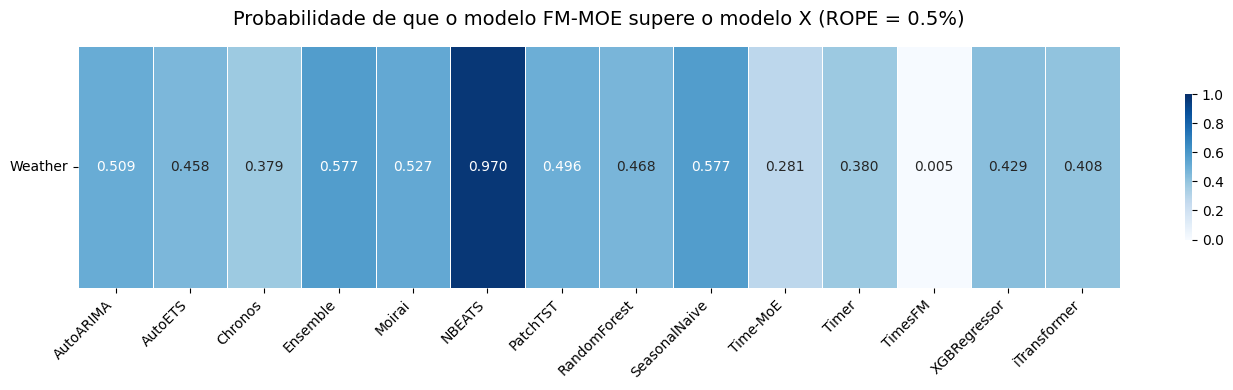

In [2]:
# ================================================
#  IMPORTS
# ================================================
import numpy as np
import pandas as pd
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt


# ================================================
#  RENAME MODEL
# ================================================
df_all["Modelo"] = df_all["Modelo"].replace("FM-MoE", "FM-MoE")
df_all["Modelo"] = df_all["Modelo"].replace("Morai", "Moirai")
df_all["Modelo"] = df_all["Modelo"].replace("Chronos-Bolt-Small", "Chronos")
df_all["Modelo"] = df_all["Modelo"].replace("Moirai-Small", "Moirai")

MY_MODEL = "FM-MoE"

# ================================================
#  1. BAYESIAN SIGNED-RANK TEST
# ================================================
def bayesian_signed_rank(differences, rope=0.5, s=0.5):
    diffs = np.array(differences)
    n_left = np.sum(diffs < -rope)
    n_rope = np.sum(np.abs(diffs) <= rope)
    n_right = np.sum(diffs > rope)
    alpha = np.array([n_left + s, n_rope + s, n_right + s])
    posterior = np.random.dirichlet(alpha, size=5000)
    return posterior[:, 0].mean(), posterior[:, 1].mean(), posterior[:, 2].mean()


# ================================================
#  2. BUILD COMBINED MATRIX (datasets x models)
# ================================================
def build_combined_matrix(df_all, my_model, rope=0.5, metric="MAPE"):
    rows = {}

    for dataset in sorted(df_all["Dataset"].unique()):
        subset = df_all[df_all["Dataset"] == dataset]

        if my_model not in subset["Modelo"].unique():
            continue

        horizon = subset["Horizonte"].iloc[0]
        # dataset.replace('_filtered', '')
        row_label = f"{dataset}"

        others = sorted([m for m in subset["Modelo"].unique() if m != my_model])

        for B in others:
            dfA = subset[subset["Modelo"] == my_model][metric].values
            dfB = subset[subset["Modelo"] == B][metric].values

            if len(dfA) != len(dfB):
                continue

            diffs = dfB - dfA
            _, _, theta_right = bayesian_signed_rank(diffs, rope)

            if row_label not in rows:
                rows[row_label] = {}
            rows[row_label][B] = theta_right

    matrix = pd.DataFrame(rows).T
    matrix = matrix.reindex(columns=sorted(matrix.columns))
    return matrix


# ================================================
#  3. PLOT COMBINED HEATMAP
# ================================================
def plot_combined_heatmap(matrix, my_model, rope=0.5):
    n_rows = len(matrix)
    n_cols = len(matrix.columns)

    fig, ax = plt.subplots(figsize=(max(14, n_cols * 1.0), max(4, n_rows * 0.7 + 2)))

    sns.heatmap(
        matrix,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor="white",
        cbar=True,
        cbar_kws={"shrink": 0.6},
        ax=ax
    )

    ax.set_title(
        f"Probabilidade de que o modelo FM-MOE supere o modelo X (ROPE = {rope}%)",
        fontsize=14, pad=15
    )
    ax.set_ylabel("")
    ax.set_xlabel("")
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()


# =============================================================
#  4. RUN
# =============================================================
rope = 0.5

print("Computing Bayesian comparisons...")
matrix = build_combined_matrix(df_all, MY_MODEL, rope=rope, metric="MAPE")

print("Generating plot...\n")
plot_combined_heatmap(matrix, MY_MODEL, rope=rope)

In [3]:
import os
import re
import numpy as np
import pandas as pd

# ========================
# CONFIG
# ========================
BASE_RESULTS_PATH = "RESULTADOS_FINAIS_BENCHMARK/results_benchmark"
# Diretório com modelos ADICIONAIS (UniTS, SimMTM, ...) incluídos em todos os
# datasets/configs. São anexados por dataset (mesmo nome de arquivo).
EXTRA_MODELS_PATH = "results_benchmark/novos_models"
MY_MOE_NAME = "FM-MoE"
ROPE = 0.5
TOP_K = 5

# Datasets considerados no ranking (nome da pasta/arquivo em disco) e o
# horizonte usado em cada um. Qualquer outro dataset presente em disco é
# ignorado nesta varredura.
DATASET_HORIZON = {
    "cif_2016_filtered":        12,
    "etth_filtered":            36,
    "hospital_filtered":        12,
    "m3_monthly_filtered":      18,
    "m4_monthly_filtered":      18,
    "nn5_weekly_filtered":       8,
    "tourism_monthly_filtered": 24,
}

# Pontos cujo erro "estoura" numericamente (ex.: 7.3e+17). Qualquer ponto em
# que ALGUM modelo apresente |valor| > EXPLOSION_THRESHOLD é descartado para
# TODOS os modelos daquele arquivo (config + dataset).
EXPLOSION_THRESHOLD = 1e6

# Oráculo simples: para cada série, considera o MENOR erro entre os
# foundation models TimesFM, Chronos, Timer e Time-MoE (o modelo vencedor
# pode mudar de uma série para outra). "Chronos-Bolt-Small" é o nome com que
# o Chronos aparece em alguns CSVs.
ORACLE_NAME = "Oráculo Simples"
ORACLE_BASE_MODELS = ["TimesFM", "Chronos", "Chronos-Bolt-Small", "Timer", "Time-MoE"]


def parse_topk(config_name):
    """Extrai o topk do nome da config (ex.: topk_2_norm_std_... -> 2)."""
    match = re.search(r"topk_(\d+)", config_name)
    return int(match.group(1)) if match else None


def drop_exploded_points(df, dataset_name="", config_name="", threshold=EXPLOSION_THRESHOLD):
    """Remove os pontos com valores estourados (|valor| > threshold) de todos os
    modelos e informa quais pontos foram descartados. Retorna (df_limpo, pontos_descartados)."""
    metric_cols = [c for c in df.columns if c != "Modelo" and not str(c).startswith("Unnamed")]
    numeric = df[metric_cols].apply(pd.to_numeric, errors="coerce")
    exploded_mask = (numeric.abs() > threshold).any(axis=0)
    dropped = [c for c in metric_cols if bool(exploded_mask.get(c, False))]
    if dropped:
        label = dataset_name + (f" / {config_name}" if config_name else "")
        print(f"[ESTOURO] {label}: pontos descartados (|valor| > {threshold:g}): {dropped}")
    return df.drop(columns=dropped), dropped


def append_extra_models(df, results_filename, extra_path=EXTRA_MODELS_PATH):
    """Anexa ao df os modelos extras (ex.: UniTS, SimMTM) presentes em
    extra_path/<results_filename>, alinhando pelas colunas de série em comum.
    Modelos já presentes no df original não são duplicados. Se o arquivo não
    existir, retorna o df inalterado."""
    extra_file = os.path.join(extra_path, results_filename)
    if not os.path.exists(extra_file):
        return df
    df_extra = pd.read_csv(extra_file)
    common_cols = [c for c in df.columns if c in df_extra.columns]
    existing = set(df["Modelo"])
    df_extra = df_extra[~df_extra["Modelo"].isin(existing)]
    if df_extra.empty:
        return df
    return pd.concat([df[common_cols], df_extra[common_cols]], ignore_index=True)


def add_simple_oracle(df, metric_cols, name=ORACLE_NAME, base_models=ORACLE_BASE_MODELS):
    """Anexa ao df a linha do oráculo simples: em cada série (coluna de
    métrica), o menor erro entre os modelos de base_models presentes no df.
    Se nenhum deles estiver no df (ex.: arquivo só com UniTS/SimMTM),
    retorna o df inalterado."""
    base = df[df["Modelo"].isin(base_models)]
    if base.empty or name in set(df["Modelo"]):
        return df
    if base["Modelo"].nunique() < 4:
        print(f"[ORÁCULO] apenas {sorted(base['Modelo'].unique())} disponíveis para o oráculo simples.")
    values = (
        base[metric_cols]
        .apply(pd.to_numeric, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
    )
    oracle = values.min(axis=0).to_frame().T
    oracle.insert(0, "Modelo", name)
    return pd.concat([df, oracle], ignore_index=True)


# ========================
# BAYESIAN FUNCTIONS
# ========================
def bayesian_signed_rank(differences, rope=0.5, s=0.5):
    diffs = np.array(differences)
    n_left  = np.sum(diffs < -rope)
    n_rope  = np.sum(np.abs(diffs) <= rope)
    n_right = np.sum(diffs > rope)
    alpha = np.array([n_left + s, n_rope + s, n_right + s])
    posterior = np.random.dirichlet(alpha, size=5000)
    return posterior.mean(axis=0)


def prob_A_better_than_B(df, A, B, rope=0.5, metric="MAPE"):
    dfA = df[df["Modelo"] == A][metric].values
    dfB = df[df["Modelo"] == B][metric].values
    if len(dfA) != len(dfB):
        raise ValueError(f"{A} e {B} com tamanhos diferentes.")
    diffs = dfB - dfA
    _, _, theta_A_better = bayesian_signed_rank(diffs, rope)
    return theta_A_better


# ========================
# PROCESSAMENTO
# ========================

results_by_dataset = {}
dropped_points_log = {}

for config_name in sorted(os.listdir(BASE_RESULTS_PATH)):
    config_path = os.path.join(BASE_RESULTS_PATH, config_name)
    if not os.path.isdir(config_path):
        continue

    topk = parse_topk(config_name)
    if topk is None:
        print(f"[SKIP] config sem topk identificável: {config_name}")
        continue

    for file in os.listdir(config_path):
        if not file.endswith(".csv"):
            continue

        # results_<dataset>.csv -> <dataset>
        dataset_name = file.replace("results_", "", 1).replace(".csv", "")

        # Considera apenas os datasets listados em DATASET_HORIZON
        if dataset_name not in DATASET_HORIZON:
            continue

        df = pd.read_csv(os.path.join(config_path, file))

        # Anexa os modelos extras (UniTS, SimMTM, ...) antes da limpeza,
        # para descarte consistente entre todos os modelos.
        df = append_extra_models(df, file)

        # Descarta pontos estourados (mesmos pontos para todos os modelos)
        df, dropped = drop_exploded_points(df, dataset_name, config_name)
        if dropped:
            dropped_points_log.setdefault(dataset_name, {})[config_name] = dropped

        # Identifica colunas de métricas (tudo exceto "Modelo")
        metric_cols = [c for c in df.columns if c != "Modelo"]

        # Oráculo simples: menor erro, série a série, entre TimesFM/Chronos/Timer/Time-MoE
        df = add_simple_oracle(df, metric_cols)

        df_long = df.melt(
            id_vars=["Modelo"],
            var_name="Serie",
            value_name="MAPE"
        )

        df_long = (
            df_long
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=["MAPE"])
        )

        modelos = df_long["Modelo"].unique()
        my_moe_models = [m for m in modelos if MY_MOE_NAME in m]

        if not my_moe_models:
            continue

        my_moe = my_moe_models[0]

        row = {
            "Config": config_name,
            "Dataset": dataset_name,
            "TopK": topk,
            "Horizonte": DATASET_HORIZON[dataset_name],
        }

        probs = []

        for other_model in modelos:
            if other_model == my_moe:
                continue
            try:
                p = prob_A_better_than_B(df_long, my_moe, other_model, rope=ROPE)
                row[f"Prob_MyMoE_vs_{other_model}"] = p
                probs.append(p)
            except ValueError:
                continue

        if not probs:
            continue

        row["Score_Medio_MyMoE"] = np.mean(probs)

        if dataset_name not in results_by_dataset:
            results_by_dataset[dataset_name] = []

        results_by_dataset[dataset_name].append(row)

# ========================
# RANKING POR DATASET / HORIZONTE / TOPK
# ========================

print("\n")

if dropped_points_log:
    print("=" * 80)
    print("PONTOS DESCARTADOS POR ESTOURO NUMÉRICO")
    print("=" * 80)
    for dataset, by_config in sorted(dropped_points_log.items()):
        print(f"{dataset}:")
        for cfg, pts in sorted(by_config.items()):
            print(f"   - {cfg}: {pts}")
    print("\n")

for dataset in [d for d in DATASET_HORIZON if d in results_by_dataset]:
    df_d = pd.DataFrame(results_by_dataset[dataset])
    horizonte = DATASET_HORIZON[dataset]

    # Um ranking separado para cada topk (top-1 e top-2 não competem entre si)
    for topk in sorted(df_d["TopK"].unique()):
        df_k = (
            df_d[df_d["TopK"] == topk]
            .sort_values("Score_Medio_MyMoE", ascending=False)
            .reset_index(drop=True)
        )

        if df_k.empty:
            continue

        # Dataset/horizonte/topk já estão no cabeçalho -> tabela mais enxuta
        df_show = df_k.drop(columns=["Dataset", "TopK", "Horizonte"])

        print("=" * 80)
        print(f"TOP {TOP_K} CONFIGS — {dataset} | horizonte = {horizonte} | topk = {topk}")
        print("=" * 80)
        print(df_show.head(TOP_K).to_string(index=False))
        print("\n")

missing_datasets = [d for d in DATASET_HORIZON if d not in results_by_dataset]
if missing_datasets:
    print(f"[AVISO] datasets sem resultados encontrados: {missing_datasets}")

[ESTOURO] etth_filtered / topk_1_norm_std_noise_True_ep_100_lr_0.0001: pontos descartados (|valor| > 1e+06): ['21', '76', '78', '88']
[ESTOURO] etth_filtered / topk_1_norm_std_noise_True_ep_100_lr_0.001: pontos descartados (|valor| > 1e+06): ['21', '76', '78', '88']
[ESTOURO] etth_filtered / topk_1_norm_std_noise_True_ep_100_lr_1e-05: pontos descartados (|valor| > 1e+06): ['21', '76', '78', '88']
[ESTOURO] etth_filtered / topk_1_norm_std_noise_True_ep_30_lr_0.0001: pontos descartados (|valor| > 1e+06): ['21', '76', '78', '88']
[ESTOURO] etth_filtered / topk_1_norm_std_noise_True_ep_30_lr_0.001: pontos descartados (|valor| > 1e+06): ['21', '76', '78', '88']
[ESTOURO] etth_filtered / topk_1_norm_std_noise_True_ep_30_lr_1e-05: pontos descartados (|valor| > 1e+06): ['21', '76', '78', '88']
[ESTOURO] etth_filtered / topk_1_norm_std_noise_True_ep_60_lr_0.0001: pontos descartados (|valor| > 1e+06): ['21', '76', '78', '88']
[ESTOURO] etth_filtered / topk_1_norm_std_noise_True_ep_60_lr_0.001: p